In [2]:
# Cell 1
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset with the CORRECT file name
# Adding column names since this specific dataset lacks a header row
columns = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']
df = pd.read_csv('twitter_training.csv', names=columns)

# Display the first 5 rows to verify the data
df.head()

,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
# Cell 2
# Check initial shape
print("Original Data Shape:", df.shape)

# Drop rows where the 'Tweet_Content' is missing (NaN)
df.dropna(subset=['Tweet_Content'], inplace=True)

# Drop duplicate rows if any exist to ensure accurate analysis
df.drop_duplicates(inplace=True)

# Remove 'Irrelevant' sentiments to focus purely on Positive, Negative, and Neutral
df = df[df['Sentiment'] != 'Irrelevant']

print("Cleaned Data Shape:", df.shape)
print("\nMissing values after cleaning:\n", df.isnull().sum())


Original Data Shape: (74682, 4)
Cleaned Data Shape: (59119, 4)

Missing values after cleaning:
 Tweet_ID         0
Entity           0
Sentiment        0
Tweet_Content    0
dtype: int64


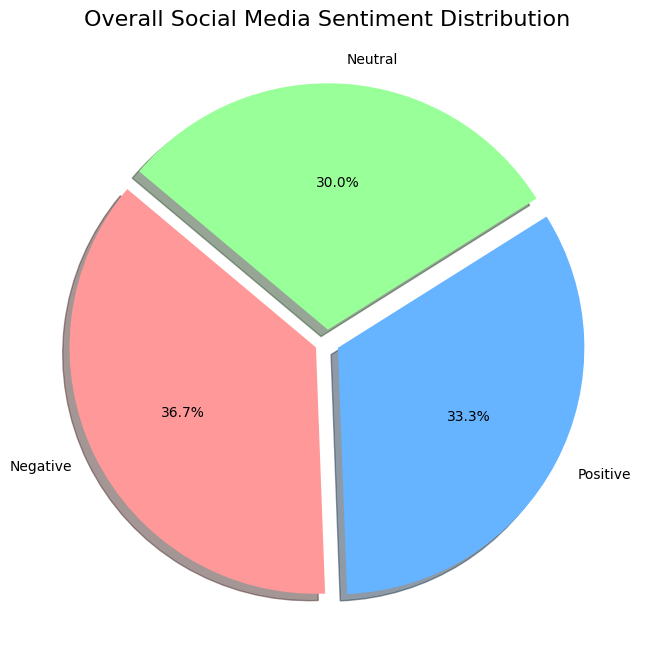

In [4]:
# Cell 3
# Analyze the overall distribution of sentiments
sentiment_counts = df['Sentiment'].value_counts()

# Create a pie chart for overall sentiment distribution
plt.figure(figsize=(8, 8))
colors = ['#ff9999','#66b3ff','#99ff99']
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, shadow=True, explode=(0.05, 0.05, 0.05))

plt.title('Overall Social Media Sentiment Distribution', fontsize=16)

# Save the visualization
plt.savefig('overall_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

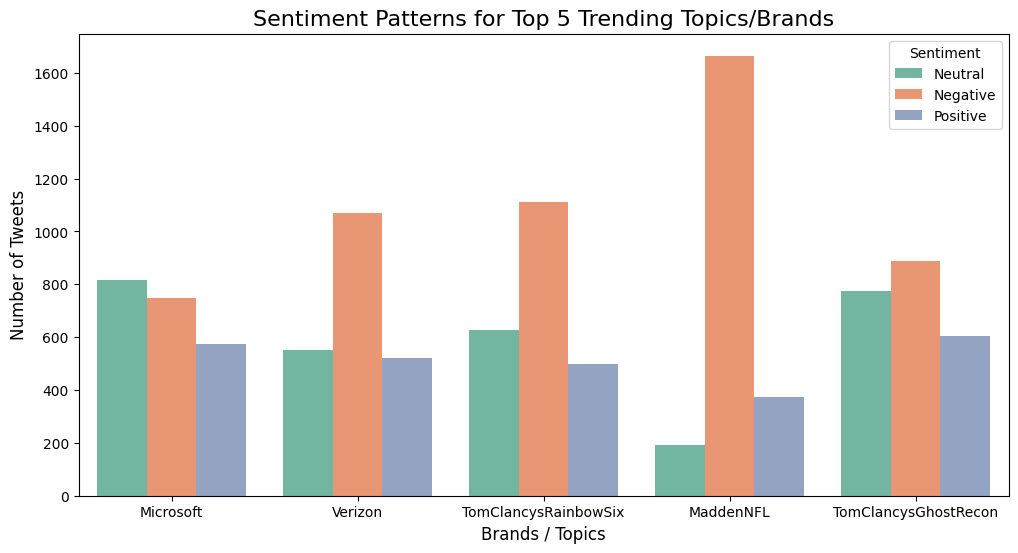

In [5]:
# Cell 4
# Identify the top 5 most discussed entities (topics/brands) in the dataset
top_5_entities = df['Entity'].value_counts().head(5).index

# Filter the dataframe to only include these top 5 entities
top_entities_df = df[df['Entity'].isin(top_5_entities)]

# Create a clustered bar chart to show sentiment breakdown for each brand/topic
plt.figure(figsize=(12, 6))
sns.countplot(data=top_entities_df, x='Entity', hue='Sentiment', palette='Set2')

plt.title('Sentiment Patterns for Top 5 Trending Topics/Brands', fontsize=16)
plt.xlabel('Brands / Topics', fontsize=12)
plt.ylabel('Number of Tweets', fontsize=12)
plt.legend(title='Sentiment')

# Save the visualization
plt.savefig('brand_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()